# 🔥 BurnSight — Colab Demo Guide

**Run the cells in order.** You can start immediately using synthetic demo data in Step 3.

> ⚡ First: Runtime → Change runtime type → Select L4 GPU

---

| Data Option | Access | Method |
|-------------|------|------|
| **A. Synthetic Data (Demo)** | Anyone | Auto-generated in Step 3 — No approval required |
| **B. De-identified Sample Data** | Researchers | Request access via `pacta300@gmail.com` |
| **C. Full Training Dataset** | Partner Institutions | Available after data-sharing agreement |

> ⚠️ Real patient images are not publicly shared for privacy protection.

## Step 1 — Clone Repository

In [1]:
GITHUB_URL = "https://github.com/cjkmj16/BurnSight.git"

import os
!git clone {GITHUB_URL} /content/BurnSight
os.chdir("/content/BurnSight")
print("Working directory:", os.getcwd())

Cloning into '/content/BurnSight'...
remote: Enumerating objects: 143, done.
remote: Counting objects: 100% (143/143), done.
remote: Compressing objects: 100% (142/142), done.
remote: Total 143 (delta 83), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (143/143), 833.12 KiB | 4.32 MiB/s, done.
Resolving deltas: 100% (83/83), done.
Working directory: /content/BurnSight


## Step 2 — Install Packages

In [2]:
%%capture
!pip install -q opencv-python-headless scikit-image imageio h5py joblib albumentations
# tensorflow / numpy / sklearn / scipy / matplotlib are preinstalled in Colab

In [3]:
import tensorflow as tf
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 3 — Prepare Data

Set `DATA_MODE`, then run only the corresponding cell below.

In [4]:
# Choose one: 'synthetic' / 'sample' / 'full'
DATA_MODE = "sample"
print("DATA_MODE:", DATA_MODE)

DATA_MODE: sample


### Step 3-A Generate Synthetic Demo Data (DATA_MODE = 'synthetic')
Generates a 6-frame synthetic wound image sequence for testing the full pipeline without approval.
Skip this cell if using real data.

In [5]:
import os, numpy as np, cv2, matplotlib.pyplot as plt

if DATA_MODE != "synthetic":
    print("Skipped — DATA_MODE is not 'synthetic'.")
else:
    SYNTHETIC_DIR = "/content/synthetic_test"
    os.makedirs(SYNTHETIC_DIR, exist_ok=True)
    np.random.seed(42)
    T, H, W = 6, 128, 128

    def make_wound_frame(t, T, H, W):
        img = np.ones((H, W, 3), np.float32) * np.array([0.82, 0.70, 0.60])  # skin tone
        heal = t / max(T - 1, 1)          # 0(initial) → 1(healed)
        cx, cy = W // 2, H // 2
        rx = int(W * 0.28 * (1 - heal * 0.35))
        ry = int(H * 0.22 * (1 - heal * 0.35))
        yy, xx = np.ogrid[:H, :W]
        wound = ((xx-cx)/rx)**2 + ((yy-cy)/ry)**2 <= 1.0
        img[wound] = [0.75 + 0.20*(1-heal), 0.25 + 0.30*heal, 0.25 + 0.25*heal]
        erx, ery = int(rx*1.15), int(ry*1.15)
        ring = (((xx-cx)/erx)**2 + ((yy-cy)/ery)**2 <= 1.0) & ~wound
        fade = max(0.0, 1.0 - heal * 1.8)
        img[ring] = img[ring] * (1 - fade*0.4) + np.array([0.30,0.20,0.15]) * fade*0.4
        img = np.clip(img + np.random.normal(0, 0.015, img.shape).astype(np.float32), 0, 1)
        return (img * 255).astype(np.uint8)

    for t in range(T):
        frame = make_wound_frame(t, T, H, W)
        cv2.imwrite(os.path.join(SYNTHETIC_DIR, f"Day{t+1}_2024010{t+1}.png"),
                    cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

    fig, axes = plt.subplots(1, T, figsize=(3*T, 3))
    for i, ax in enumerate(axes):
        img = cv2.cvtColor(cv2.imread(os.path.join(SYNTHETIC_DIR, f"Day{i+1}_2024010{i+1}.png")), cv2.COLOR_BGR2RGB)
        ax.imshow(img); ax.set_title(f"Day {i+1}"); ax.axis("off")
    plt.suptitle("Synthetic Wound Sequence (Demo Only — Not Real Patient Images)", fontsize=11)
    plt.tight_layout(); plt.show()

    TEST_DIR = SYNTHETIC_DIR
    print("\n✅ Synthetic demo data ready:", TEST_DIR)

Skipped — DATA_MODE is not 'synthetic'.


### Step 3-B/C　Real Data (DATA_MODE = 'sample' or 'full')
Run only if access has been approved.

In [6]:
if DATA_MODE == "synthetic":
    print("Skipped — synthetic mode enabled.")
else:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = "/content/drive/MyDrive"

    # ✏️  Replace with your approved Google Drive folder path
    TEST_DIR         = f"{DRIVE_ROOT}/test(15)"
    MASK_MODEL_PATH  = f"{DRIVE_ROOT}/unet5_final.keras"
    CREATOR_PATH     = f"{DRIVE_ROOT}/creator_model.keras"

    for label, path in [("TEST_DIR", TEST_DIR), ("MASK_MODEL_PATH", MASK_MODEL_PATH), ("CREATOR_PATH", CREATOR_PATH)]:
        print(("✅" if os.path.exists(path) else "❌ Missing"), label, ":", path)

Mounted at /content/drive
✅ TEST_DIR : /content/drive/MyDrive/test(7)
✅ MASK_MODEL_PATH : /content/drive/MyDrive/unet5_final.keras
✅ CREATOR_PATH : /content/drive/MyDrive/creator_model.keras


## Step 4 — Patch config.py Paths

In [7]:
import os
from pathlib import Path
from google.colab import drive
drive.mount('/content/drive')

CACHE_DIR = "/content/cache_dir"
os.makedirs(CACHE_DIR, exist_ok=True)

# In synthetic mode only TEST_DIR is required; others are placeholders
BASE_DIR    = TEST_DIR if DATA_MODE == "synthetic" else TEST_DIR
ORIGIN_DIR  = TEST_DIR
AUG_DIR     = "/content/drive/MyDrive/wd_aug(3)"

CONFIG = f'''
import os, warnings, random
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras.mixed_precision import set_global_policy
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from joblib import Memory

set_global_policy("float32")
warnings.filterwarnings("ignore", category=DeprecationWarning)

base_dir          = r"{BASE_DIR}"
original_test_dir = r"{TEST_DIR}"
cache_dir         = r"{CACHE_DIR}"
ORIGIN_DIR        = r"{ORIGIN_DIR}"
AUG_DIR           = r"{AUG_DIR}"
memory            = Memory(cache_dir, verbose=0)

physical_devices = tf.config.experimental.list_physical_devices("GPU")
if physical_devices:
    try: tf.config.experimental.set_memory_growth(physical_devices[0], True)
    except: pass

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)

SEQLEN = SEQ_LEN = sequence_length = 6
IMG_SIZE = (64, 64); IMG_H = IMG_W = 64
BATCH = 8; VAL_RATIO = 0.10; MAX_T = 12; STRIDE = 1
NUM_CLASSES = 5; WOUND_IDX = 1; ESCHAR_IDX = 2; HEALED_IDX = 3; EXCLUDE_IDX = 4
LESION_IDXS = (1, 2, 3); CHANGE_IDXS = (1, 2); STABLE_IDXS = (0, 3); POLICY_VER = 3
K_MIN = 0; K_MAX = 5; K_VAL = 5
THR_WOUND = 0.55; THR_SUPPORT = 0.45; THR_CHANGE = 0.40
LATENT_DIM = 256; CTX_K = 6; DELTA_MIN = 1; DELTA_MAX = 5
TAU_NCE = 0.1; TAU_ANTI = 0.03; PATCH_K = 32; TOPK_RATIO = 0.3
LR_STAGE1 = 1e-4; LR_STAGE2 = 1e-4
AUTOTUNE = tf.data.AUTOTUNE
input_shape = (None, 64, 64, 3); sequence_tensor = tf.constant(5); batch_size = 4
ckpt    = ModelCheckpoint("creator_model.keras", monitor="val_cos", save_best_only=True, mode="max", verbose=1)
early   = EarlyStopping(monitor="val_cos", patience=20, mode="max", restore_best_weights=True)
plateau = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=10, min_lr=1e-5, verbose=1)
DEBUG_ROOT = Path(cache_dir) / "debug"; DEBUG_ROOT.mkdir(parents=True, exist_ok=True)
debug_dir  = DEBUG_ROOT / "dbg_inverted"; debug_dir.mkdir(exist_ok=True)
DBG_LIST   = debug_dir / "inverted_list.txt"
def log_inverted(tag, img_path, mask_path):
    with open(DBG_LIST, "a") as f: f.write(f"{{tag}}\\t{{img_path}}\\t{{mask_path}}\\n")
def _to_str(x):
    x = x.numpy() if hasattr(x, "numpy") else x
    return x.decode("utf-8", "ignore") if isinstance(x, (bytes, np.bytes_)) else str(x)
'''

with open("src/config.py", "w") as f:
    f.write(CONFIG)
print("✅ src/config.py patched successfully.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ src/config.py patched successfully.


## Step 5 — Load Pretrained Models

In [8]:
import tensorflow as tf, sys
sys.path.insert(0, "/content/BurnSight")

from src.config import *
from src.data.file_utils import *
from src.models.layers import *
from src.models.unet import *
from src.utils.image_utils import *
from src.inference.mask_utils import *
from src.inference.postprocess import *

if DATA_MODE == "synthetic":
    print("⚠️  Synthetic mode: pipeline structure only (no pretrained models loaded).")
    print("   For real inference, request model access and update DATA_MODE.")
    mask_model = None
    creator    = None
else:
    mask_model = tf.keras.models.load_model(
        MASK_MODEL_PATH,
        custom_objects={
            'soft_dice_metric': soft_dice_metric,
            'seg_loss': seg_loss,
            'MNV2Preprocess': MNV2Preprocess
        }
    )
    creator = tf.keras.models.load_model(
        CREATOR_PATH,
        custom_objects={
            'L2Normalize': L2Normalize,
            'SoftDilate': SoftDilate,
            'TileCutter1': TileCutter1,
            'TileCutter2': TileCutter2,
            'SequenceLengthLayer': SequenceLengthLayer,
            'TimePreservingUpSampling2D': TimePreservingUpSampling2D,
            'RGBSlice': RGBSlice,
            'KSlice': KSlice,
            'MSlice': MSlice,
            'ScaleBias': ScaleBias,
            'SoftClip': SoftClip,
            'GatedSkip': GatedSkip,
            'TanhWithTemp': TanhWithTemp,
            'ScaledTanh': ScaledTanh,
            'GateScale': GateScale,
            'OnesLike': OnesLike,
            'XLastPicker': XLastPicker,
            'DebugPrint': DebugPrint,
            'TemporalAttentionPooling': TemporalAttentionPooling,
            'SoftClamp': SoftClamp,
            'SelectLastTime': SelectLastTime,
            'FloatCastLayer': FloatCastLayer,
            'RepeatChannels3': RepeatChannels3,
        },
        compile=False
    )

    print("✅ mask_model:", mask_model.input_shape)
    print("✅ creator:   ", creator.input_shape)

if DATA_MODE != "synthetic":
    mask = unet(input_shape=(64,64,3), weights='imagenet')
    mask.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss=seg_loss,
                metrics=[soft_dice_metric])

train seqs: 954  val seqs: 86
train seqs: 954  val seqs: 86
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_attention_pooling', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


✅ mask_model: (None, 64, 64, 3)
✅ creator:    (None, None, 64, 64, 5)


/content/BurnSight/src/models/unet.py:246: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


## Step 6 — Load Test Sequence

6 images found
Sequence shape: (1, 6, 64, 64, 3)


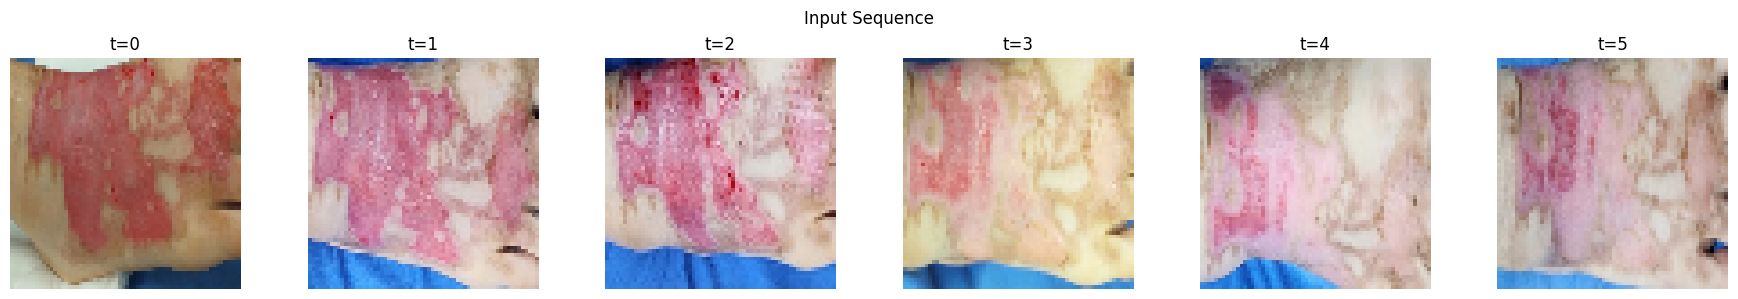

In [9]:
import numpy as np, cv2, matplotlib.pyplot as plt

sorted_image_files = get_sorted_day_images(TEST_DIR)
print(f"{len(sorted_image_files)} images found")

example_sequence = []
for path in sorted_image_files:
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (64, 64)).astype(np.float32) / 255.0
    example_sequence.append(img)

example_sequence = np.asarray(example_sequence, dtype=np.float32)[None, ...]  # (1,T,64,64,3)

T = example_sequence.shape[1]
if T > SEQLEN:
    example_sequence = example_sequence[:, -SEQLEN:]
elif T < SEQLEN:
    pad = np.repeat(example_sequence[:, :1], SEQLEN - T, axis=1)
    example_sequence = np.concatenate([pad, example_sequence], axis=1)

print("Sequence shape:", example_sequence.shape)

fig, axes = plt.subplots(1, SEQLEN, figsize=(3*SEQLEN, 3))
for t, ax in enumerate(axes):
    ax.imshow(example_sequence[0, t]); ax.set_title(f"t={t}"); ax.axis("off")
plt.suptitle("Input Sequence"); plt.tight_layout(); plt.show()

## Step 7 — Generate ROI Gate (m_soft)
*In synthetic mode, a dummy ROI is used instead of a trained model.*

[thr] scope=sequence reduce=median t_used_seq=0.5500 which=global reasons=[]
ROI info: {'t_used_seq': 0.55, 'which_seq': 'global', 'reasons_seq': [], 'roi_frac_mean': 0.5077311396598816}


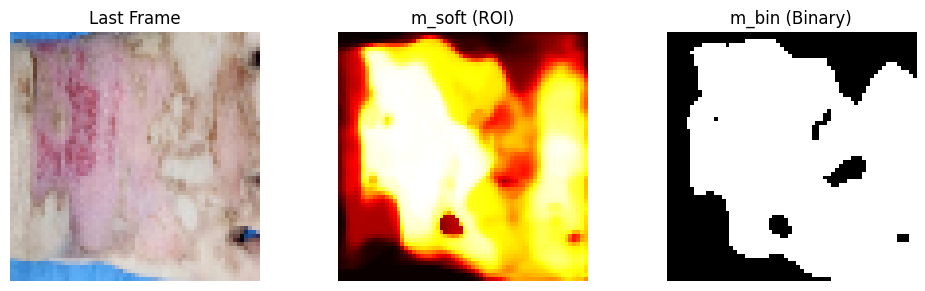

In [10]:
if mask_model is None:
    # Synthetic mode: centered elliptical dummy ROI
    B, T, H, W, _ = example_sequence.shape
    yy, xx = np.ogrid[:H, :W]
    ellipse = ((xx - W//2)/(W*0.28))**2 + ((yy - H//2)/(H*0.22))**2 <= 1.0
    m_soft = np.tile(ellipse.astype(np.float32)[None,None,...,None], (B,T,1,1,1))
    m_bin  = (m_soft > 0.5).astype(np.float32)
    print("Dummy ROI generated (synthetic mode)")
else:
    def preprocess_infer_seq(x): return x * 2.0 - 1.0
    m_soft, m_bin, roi_info = make_fixed_msoft_from_seq(
        example_sequence, mask_model, preprocess=preprocess_infer_seq,
        THR=THR_WOUND, mode="mixed", tau=0.30, ema_alpha=0.4,
        temp_T=0.9, use_tta=True, thr_scope="sequence", thr_reduce="median",
    )
    print("ROI info:", roi_info)

fig, axes = plt.subplots(1, 3, figsize=(10, 3))
axes[0].imshow(example_sequence[0,-1]);              axes[0].set_title("Last Frame");  axes[0].axis("off")
axes[1].imshow(m_soft[0,-1,...,0], cmap="hot");      axes[1].set_title("m_soft (ROI)"); axes[1].axis("off")
axes[2].imshow(m_bin[0,-1,...,0],  cmap="gray");     axes[2].set_title("m_bin (Binary)"); axes[2].axis("off")
plt.tight_layout(); plt.show()

## Step 8 — K-sweep Inference
Generates healing prediction images at K = 0.2 / 0.6 / 1.0  
*In synthetic mode, only K-channel visualization is shown because no creator model is loaded.*

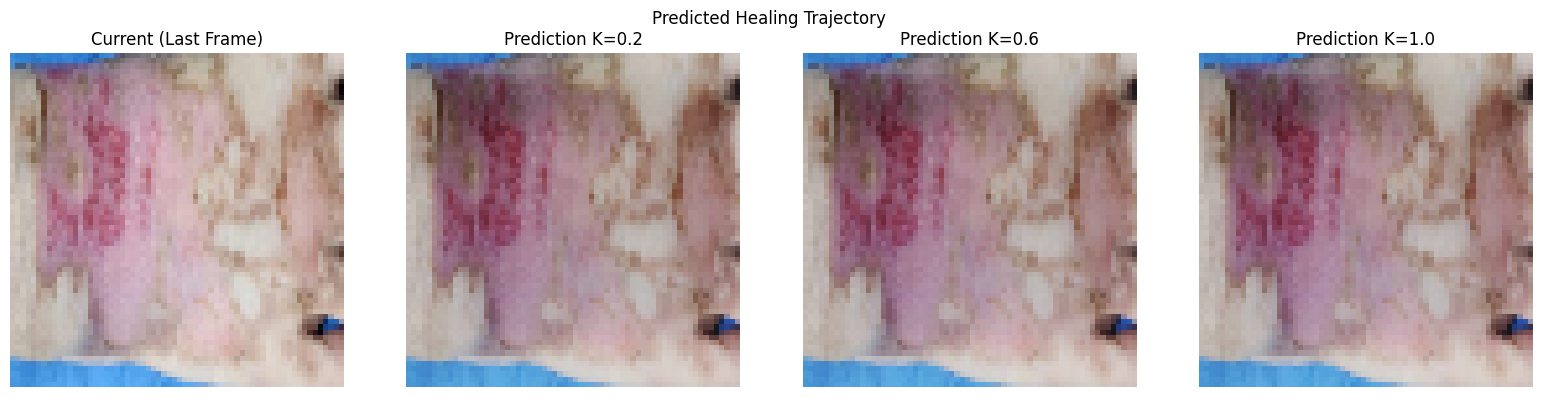

In [11]:
import cv2

K_vals = [0.2, 0.6, 1.0]
results = {}

last01 = example_sequence[0, -1]  # (64,64,3)

for k in K_vals:
    if creator is None:
        # Synthetic mode: brightness adjusted inside ROI proportional to K
        pred = last01.copy()
        roi2d = m_soft[0, -1, ..., 0] > 0.5
        pred[roi2d] = np.clip(pred[roi2d] * (1 - k * 0.25) + k * 0.08, 0, 1)
    else:
        rgb_m11 = example_sequence * 2.0 - 1.0
        k_map   = np.full(m_soft.shape, k / float(K_MAX), np.float32)
        Xk      = np.concatenate([rgb_m11, k_map, m_soft], axis=-1)
        y_pred, x_last = creator.predict(Xk, verbose=0)
        pred    = np.clip((y_pred[0] + 1.0) / 2.0, 0, 1).astype(np.float32)
        last01  = np.clip((x_last[0] + 1.0) / 2.0, 0, 1).astype(np.float32)

    results[k] = pred

fig, axes = plt.subplots(1, len(K_vals) + 1, figsize=(4*(len(K_vals)+1), 4))
axes[0].imshow(last01); axes[0].set_title("Current (Last Frame)"); axes[0].axis("off")
for i, k in enumerate(K_vals):
    axes[i+1].imshow(results[k]); axes[i+1].set_title(f"Prediction K={k}"); axes[i+1].axis("off")
label = "(Dummy Visualization — No Real Model)" if creator is None else ""
plt.suptitle(f"Predicted Healing Trajectory {label}", fontsize=12)
plt.tight_layout(); plt.show()

def rgb01_to_lab(img01):
    x8 = (np.clip(img01, 0, 1) * 255).astype(np.uint8)
    return cv2.cvtColor(x8, cv2.COLOR_RGB2LAB).astype(np.float32)

pred01  = results[1.0]
roi_2d  = m_soft[0, -1, ..., 0]
roi_mask = roi_2d > 0.5

Lab_l   = rgb01_to_lab(last01)
Lab_p   = rgb01_to_lab(pred01)
d       = Lab_p - Lab_l
dE      = np.sqrt(np.sum(d**2, axis=-1))
da_star = d[..., 1]

da_roi  = np.where(roi_mask, da_star, 0.0)
dE_roi  = np.where(roi_mask, dE,      0.0)

da_out_val  = float(np.mean(np.abs(da_star[~roi_mask]))) if (~roi_mask).any() else 0.0
da_roi_val  = float(np.mean(da_star[roi_mask]))           if roi_mask.any()   else 0.0
dE_roi_val  = float(np.mean(dE[roi_mask]))                if roi_mask.any()   else 0.0

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle(f"FINAL_OPT | Δa*_roi={da_roi_val:.3f}, Δa*_out={da_out_val:.3f}, ΔE_roi={dE_roi_val:.3f}")
axes[0].imshow(last01);  axes[0].set_title("last");  axes[0].axis("off")
axes[1].imshow(pred01);  axes[1].set_title("pred");  axes[1].axis("off")
im2 = axes[2].imshow(da_roi, cmap="bwr", vmin=-10, vmax=10)
axes[2].set_title("Δa* (redness)"); axes[2].axis("off"); plt.colorbar(im2, ax=axes[2])
im3 = axes[3].imshow(dE_roi, cmap="inferno", vmin=0)
axes[3].set_title("ΔE"); axes[3].axis("off"); plt.colorbar(im3, ax=axes[3])
plt.tight_layout(); plt.show()

## Step 9 — Lab Color Change Analysis (Δa*, ΔE)

  K  Δa*_ROI (Redness Change)  ΔE_ROI (Overall Color Change)
0.2                    1.6272                        30.2378
0.6                    1.8754                        30.4741
1.0                    2.1632                        30.6401


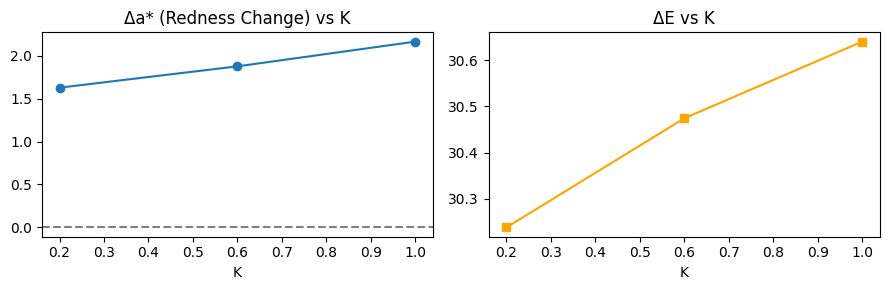

In [12]:
import pandas as pd, cv2

def rgb01_to_lab(img01):
    x8 = (np.clip(img01, 0, 1) * 255).astype(np.uint8)
    return cv2.cvtColor(x8, cv2.COLOR_RGB2LAB).astype(np.float32)

roi_w = m_soft[0, -1, ..., 0]  # (64,64)
rows = []
for k in K_vals:
    Lab_l = rgb01_to_lab(last01)
    Lab_p = rgb01_to_lab(results[k])
    d = Lab_p - Lab_l
    dE = np.sqrt(np.sum(d**2, axis=-1))
    w  = np.clip(roi_w, 0, 1)
    wsum = w.sum() + 1e-6
    rows.append({"K": k,
                 "Δa*_ROI (Redness Change)": round(float((d[...,1]*w).sum()/wsum), 4),
                 "ΔE_ROI (Overall Color Change)": round(float((dE*w).sum()/wsum), 4)})

df = pd.DataFrame(rows)
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(df["K"], df["Δa*_ROI (Redness Change)"], "o-")
axes[0].axhline(0, ls="--", color="gray")
axes[0].set_xlabel("K"); axes[0].set_title("Δa* (Redness Change) vs K")
axes[1].plot(df["K"], df["ΔE_ROI (Overall Color Change)"], "s-", color="orange")
axes[1].set_xlabel("K"); axes[1].set_title("ΔE vs K")
plt.tight_layout(); plt.show()

---
## ✅ Done!

The full pipeline completed successfully:
- Step 1–2: Repository clone + package installation
- Step 3: Data preparation (synthetic or real)
- Step 4: Automatic config patching
- Step 5: Model loading
- Step 6–7: Sequence loading + ROI gating
- Step 8–9: K-sweep inference + color analysis

**To run real-model inference:**
Please contact `pacta300@gmail.com` for access and change `DATA_MODE='sample'`.
